# Load Dataset And Show Basic Information

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
verbose = True   # Whether to output detailed information.
dataset = 'lastfm'   # Select the dataset to process, select from ['ml-100k', 'ml-1m', 'lfm-2b'].

In [3]:
def drawing_histogram(attribute, attribute_dict):
    data = np.array(list(attribute_dict.values))
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of Data Distribution: {attribute}')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.show()

In [4]:
def verbose_dataset_info(interactions, users_data):
    print("DATASET INFORMATION:")
    users_size = interactions['uid'].nunique()
    print(f"\tNumber of users: {users_size}, index: {min(interactions['uid'])}-{max(interactions['uid'])}")
    items_size = interactions['iid'].nunique()
    print(f"\tNumber of items: {items_size}, index: {min(interactions['iid'])}-{max(interactions['iid'])}")

    interaction_size = len(interactions)
    print(f"\tNumber of ratings: {interaction_size}")
    sparsity = (users_size * items_size - interaction_size) / (users_size * items_size)
    print(f"\tSparsity: {sparsity} = {users_size * items_size - interaction_size} / {users_size * items_size}")

    print("ATTRIBUTES INFORMATION:")
    for attribute in users_data.columns[1:]:
        print(
            f"\tAttribute: {attribute}, {users_data[attribute].nunique()} unique values, {type(users_data[attribute][0])}")
        drawing_histogram(attribute, users_data[attribute])

In [5]:
def load_ml_100k(verbose=True):
    interactions = pd.read_csv('./ml-100k/raw/u.data', header=None, sep='\t',
                               names=['uid', 'iid', 'rating', 'timestamp'], engine='python')
    users_data = pd.read_csv('./ml-100k/raw/u.user', header=None, sep='|',
                             names=['uid', 'age', 'gender', 'occupation', 'zip'],
                             usecols=['uid', 'gender', 'age'], engine='python')

    if verbose:
        verbose_dataset_info(interactions, users_data)

    return interactions, users_data

In [6]:
def load_ml_1m(verbose=True):
    interactions = pd.read_csv('./ml-1m/raw/ratings.dat', header=None, sep='::',
                               names=['uid', 'iid', 'rating', 'timestamp'], engine='python')
    users_data = pd.read_csv('./ml-1m/raw/users.dat', header=None, sep='::',
                             names=['uid', 'gender', 'age', 'occupation', 'zip'],
                             usecols=['uid', 'gender', 'age'], engine='python')

    if verbose:
        verbose_dataset_info(interactions, users_data)

    return interactions, users_data

In [7]:
def load_lastfm(verbose=True):
    ratings = pd.read_csv('./lastfm/raw/ratings.tsv', header=None, sep='\t', names=['uid', 'iid', '1', '2'], usecols=['uid', 'iid'])
    users_data = pd.read_csv('./lastfm/raw/users.tsv', header=None, sep='\t', names=['uid', 'gender', 'age', '_1', '_2'], usecols=['uid', 'gender', 'age'])
    
    users_data = users_data.dropna(subset=['gender', 'age'])
    users_unique = users_data.uid.unique()
    ratings = ratings[ratings['uid'].isin(users_unique)]
    users_unique = ratings.uid.unique()
    users_data = users_data[users_data['uid'].isin(users_unique)]
    uid_mapping = {uid: idx for idx, uid in enumerate(ratings['uid'].unique())}
    iid_mapping = {iid: idx for idx, iid in enumerate(ratings['iid'].unique())}
    ratings['uid'] = ratings['uid'].map(uid_mapping)
    ratings['iid'] = ratings['iid'].map(iid_mapping)
    ratings['timestamp'] = [i for i in range(len(ratings))]
    users_data['uid'] = users_data['uid'].map(uid_mapping).astype(int)
    users_data['age'] = users_data['age'].astype(int)
    users_data = users_data[(users_data['age'] >= 0) & (users_data['age'] <= 100)]
    if verbose:
        verbose_dataset_info(ratings, users_data)
            
    return ratings, users_data

In [8]:
def load_lfm_2b(verbose=True):
    interactions = pd.read_csv('./lfm-2b/raw/listening_events.tsv', header=0, sep='\t',
                               names=['uid', 'iid', 'aid', 'timestamp'], dtype={'uid': 'int64', 'iid': 'int64'},
                               engine='python')
    # Convert time to timestamp.
    interactions['timestamp'] = pd.to_datetime(interactions['timestamp'])
    interactions['timestamp'] = interactions['timestamp'].astype(int) // 10**9
    users_data = pd.read_csv('./lfm-2b/raw/users.tsv', header=0, sep='\t',
                             names=['uid', 'country', 'age', 'gender', 'creation_time'],
                             usecols=['uid', 'gender'], engine='python')
    # Remove users whose gender is None and 'n'.
    users_delete = users_data[((users_data['gender'] == 'n') | (users_data['gender'].isna()))]
    users_retain = users_data[~((users_data['gender'] == 'n') | (users_data['gender'].isna()))]
    delete_set = list(users_delete['uid'])
    interactions_retain = interactions[~interactions['uid'].isin(delete_set)]
    if verbose:
        verbose_dataset_info(interactions_retain, users_retain)

    return interactions_retain, users_retain

In [9]:
def load_dataset(dataset_name='ml-100k', verbose=True):
    if dataset_name == 'ml-100k':
        return load_ml_100k(verbose=verbose)
    elif dataset_name == 'ml-1m':
        return load_ml_1m(verbose=verbose)
    elif dataset_name == 'lfm-2b':
        return load_lfm_2b(verbose=verbose)
    elif dataset_name == 'lastfm':
        return load_lastfm(verbose=verbose)
    else:
        raise ValueError(f'Dataset {dataset_name} not supported')

DATASET INFORMATION:
	Number of users: 267034, index: 0-267033
	Number of items: 145975, index: 0-145974
	Number of ratings: 13068502
	Sparsity: 0.99966474075436 = 38967219648 / 38980288150
ATTRIBUTES INFORMATION:
	Attribute: gender, 2 unique values, <class 'str'>


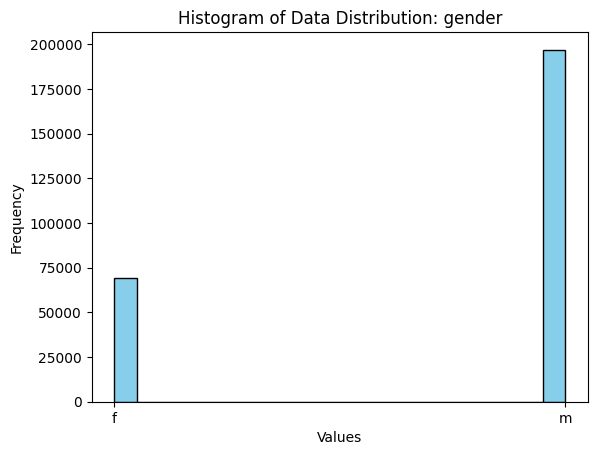

	Attribute: age, 100 unique values, <class 'numpy.int64'>


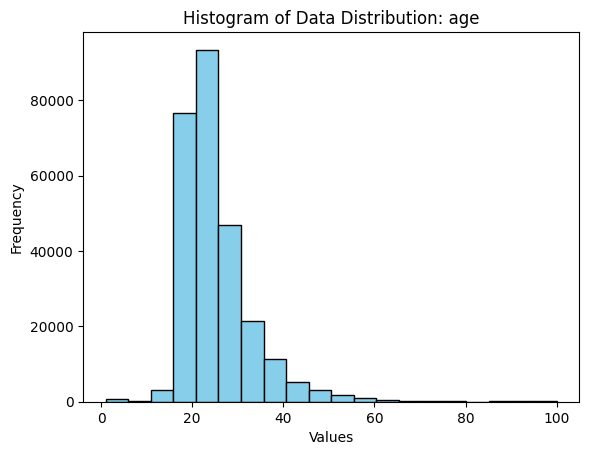

In [10]:
interactions_original, users_data_original = load_dataset(dataset, verbose)

# Data Cleaning


In [11]:
import os

In [54]:
item_threshold = 23 # Set the minimum number of item interactions for filtering.
user_threshold = 51 # User's threshold

In [55]:
def data_cleaning(interactions, users_data, dataset, user_threshold=5, item_threshold=5, verbose=True):
    while True:
        filter_num = 0
        del_user, del_item = [], []
        aggregate_user_interaction = interactions.groupby('uid').agg(len)
        user_index = aggregate_user_interaction.iid < user_threshold
        del_user_num = sum(user_index)
        if del_user_num > 0:
            del_user = list(aggregate_user_interaction[user_index].index)
            filter_num += 1
        if verbose:
            print(f"Data cleaning, threshold {user_threshold}, delete {del_user_num} users")
        interactions = interactions[~np.isin(interactions.uid.values, del_user)]
        users_data = users_data[~np.isin(users_data.uid.values, del_user)]
        if verbose:
            print(
                f"{interactions.uid.nunique()} = {users_data.uid.nunique()} unique users, {interactions.iid.nunique()} unique items")

        aggregate_item_interaction = interactions.groupby('iid').agg(len)
        item_index = aggregate_item_interaction.uid < item_threshold
        del_item_num = sum(item_index)
        if del_item_num > 0:
            del_item = list(aggregate_item_interaction[item_index].index)
            filter_num += 1
        if verbose:
            print(f"Data cleaning, threshold {item_threshold}, delete {del_item_num} items")
        old_user_pool = set(interactions.uid.values)
        interactions = interactions[~np.isin(interactions.iid.values, del_item)]
        new_user_pool = set(interactions.uid.values)
        users_data = users_data[~np.isin(users_data.uid.values, list(old_user_pool - new_user_pool))]
        if verbose:
            print(
                f"{interactions.uid.nunique()} = {users_data.uid.nunique()} unique users, {interactions.iid.nunique()} unique items")
        if filter_num == 0:
            break
    # Ensure the number of genders is balanced
    gender_counts = users_data['gender'].value_counts()
    min_gender_count = gender_counts.min()
    balanced_users = users_data.groupby('gender').apply(lambda x: x.sample(min_gender_count, random_state=42)).reset_index(drop=True)
    retained_uids = set(balanced_users['uid'])
    interactions = interactions[interactions['uid'].isin(retained_uids)]
    users_data = users_data[users_data['uid'].isin(retained_uids)]
    
    user_index_mapping = {}
    for new_idx, old_idx in enumerate(sorted(interactions.uid.unique())):
        user_index_mapping[old_idx] = new_idx
    interactions.loc[:, 'uid'] = interactions.uid.map(user_index_mapping)
    users_data.loc[:, 'uid'] = users_data.uid.map(user_index_mapping)

    item_index_mapping = {}
    for new_idx, old_idx in enumerate(sorted(interactions.iid.unique())):
        item_index_mapping[old_idx] = new_idx
    interactions.loc[:, 'iid'] = interactions.iid.map(item_index_mapping)

    interactions = interactions.sort_values(by=['uid', 'iid'])
    interactions.reset_index(drop=True, inplace=True)
    users_data.reset_index(drop=True, inplace=True)
    if verbose:
        verbose_dataset_info(interactions, users_data)

    return interactions, users_data


Data cleaning, threshold 51, delete 193251 users
73783 = 73517 unique users, 112361 unique items
Data cleaning, threshold 23, delete 93785 items
73783 = 73517 unique users, 18576 unique items
Data cleaning, threshold 51, delete 29885 users
43898 = 43729 unique users, 18576 unique items
Data cleaning, threshold 23, delete 6465 items
43898 = 43729 unique users, 12111 unique items
Data cleaning, threshold 51, delete 10019 users
33879 = 33750 unique users, 12111 unique items
Data cleaning, threshold 23, delete 2346 items
33879 = 33750 unique users, 9765 unique items
Data cleaning, threshold 51, delete 5043 users
28836 = 28730 unique users, 9765 unique items
Data cleaning, threshold 23, delete 1243 items
28836 = 28730 unique users, 8522 unique items
Data cleaning, threshold 51, delete 3092 users
25744 = 25653 unique users, 8522 unique items
Data cleaning, threshold 23, delete 755 items
25744 = 25653 unique users, 7767 unique items
Data cleaning, threshold 51, delete 2013 users
23731 = 23648

/tmp/ipykernel_8837/1941445874.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_users = users_data.groupby('gender').apply(lambda x: x.sample(min_gender_count, random_state=42)).reset_index(drop=True)


	Number of items: 3834, index: 0-3833
	Number of ratings: 339032
	Sparsity: 0.9855415710112234 = 23109712 / 23448744
ATTRIBUTES INFORMATION:
	Attribute: gender, 2 unique values, <class 'str'>


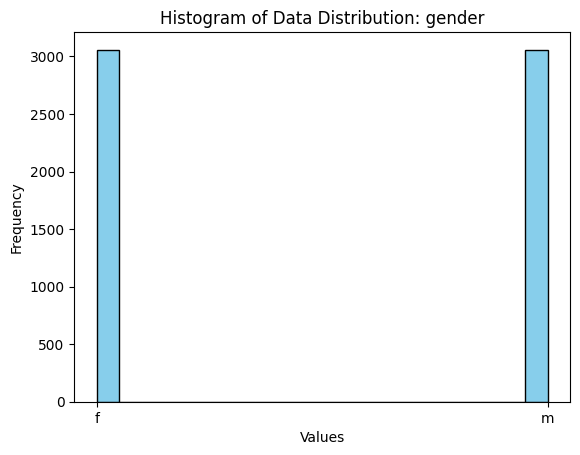

	Attribute: age, 70 unique values, <class 'numpy.int64'>


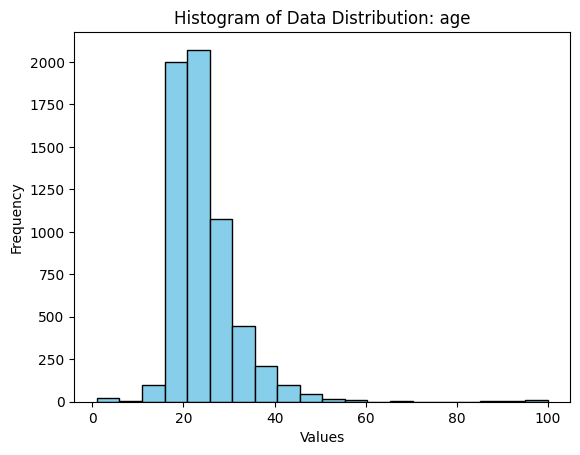

In [56]:
interactions, users_data = data_cleaning(interactions_original, users_data_original, dataset, user_threshold, item_threshold, verbose)

# Save attribute dictionary

In [57]:
# 针对不同数据集设置年龄分组区间
if dataset == 'ml-1m':
    age_bins = [25, 31]
elif dataset == 'ml-100k':
    age_bins = [27, 38]
elif dataset == 'lastfm':
    age_bins = [21, 26]


In [58]:
def split_age(users_data, uid, age_bins):
    """
    根据传入的age_bins对用户年龄进行分组。
    age_bins: 一个升序排列的列表，例如[25, 31]，会分成len(age_bins)+1组。
    返回：分组编号，从0开始。
    """
    age = users_data[users_data['uid'] == uid].age.item()
    for idx, bin_edge in enumerate(age_bins):
        if age < bin_edge:
            return idx
    return len(age_bins)


def save_attribute_dict(users_data, dataset, user_threshold=5, item_threshold=5, verbose=True):
    save_path = f"./{dataset}/preprocess/"
    os.makedirs(save_path, exist_ok=True)
    gender_dict = {}
    age_dict = {}

    if 'gender' in users_data.columns:
        for uid in users_data.uid.values:
            gender_dict[uid] = users_data[users_data['uid'] == uid].gender.item()
        np.save(save_path + f'user_gender.npy', gender_dict)
        if verbose:
            for gender in list(set(gender_dict.values())):
                print(f"number of attribute {gender} is {list(gender_dict.values()).count(gender)}")

    if 'age' in users_data.columns:
        for uid in users_data.uid.values:
            age_dict[uid] = split_age(users_data, uid, age_bins)
        np.save(save_path + f'user_age.npy', age_dict)
        if verbose:
            for age_group in range(3):
                print(f"number of age group {age_group} is {list(age_dict.values()).count(age_group)}")


In [59]:
save_attribute_dict(users_data, dataset, user_threshold, item_threshold, verbose)

number of attribute f is 3058
number of attribute m is 3058
number of age group 0 is 2117
number of age group 1 is 2072
number of age group 2 is 1927


# Negative Sampling And Generate Interaction For Training / Testing

In [60]:
import random

In [61]:
num_neg = 99 # The number of negative samples, each user has one positive sample and 99 negative samples.
random.seed(42) # This experiment was conducted with a seed of 42.

In [62]:
def generate_train_test_interaction(interactions, dataset, user_threshold=5, item_threshold=5, num_neg=99,
                                    verbose=True):
    interactions['latest'] = interactions.groupby('uid')['timestamp'].rank(method='first', ascending=False)
    test = interactions[interactions['latest'] == 1]
    train = interactions[interactions['latest'] > 1]
    train_interaction = train[['uid', 'iid']]
    test_interaction = test[['uid', 'iid']]
    if verbose:
        print(f"Number of users in test {test['uid'].nunique()}, in train {train['uid'].nunique()}")

    save_path = f"./{dataset}/preprocess/"
    os.makedirs(save_path, exist_ok=True)
    train_interaction.to_csv(os.path.join(save_path, 'train_interactions.csv'), header=False, index=False)

    item_pool = set(interactions['iid'].unique())
    interact_status = interactions.groupby('uid')['iid'].apply(set).reset_index().rename(
        columns={'iid': 'interacted_items'})
    interact_status['negative_items'] = interact_status['interacted_items'].apply(
        lambda x: set(random.sample(list(item_pool), (num_neg + len(x)))) - x)
    interact_status['negative_samples'] = interact_status['negative_items'].apply(
        lambda x: random.sample(list(x), num_neg))
    test_interaction = pd.merge(test_interaction, interact_status[['uid', 'negative_samples']], on='uid')
    with open(os.path.join(save_path, 'test_neg_interactions'), 'w') as f:
        for row in test_interaction.itertuples():
            t_rating = (int(row.uid), int(row.iid))
            f.write(str(t_rating))
            for i in range(len(row.negative_samples)):
                f.write('\t')
                f.write(str(row.negative_samples[i]))
            f.write('\n')

    return train_interaction, test_interaction

In [63]:
train_interaction, test_interaction = generate_train_test_interaction(interactions, dataset, user_threshold, item_threshold,
                                                                      num_neg, verbose)

Number of users in test 6116, in train 6116


# Generate Positive Dict For Convenience

In [64]:
def generate_positive_dict(train_interaction, dataset, user_threshold=5, item_threshold=5, verbose=True):
    train_interaction = train_interaction.values.tolist()
    train_positive_dict = {}

    for interaction in train_interaction:
        if interaction[0] not in train_positive_dict.keys():
            train_positive_dict[interaction[0]] = []
        train_positive_dict[interaction[0]].append(interaction[1])

    save_path = f"./{dataset}/preprocess/"
    os.makedirs(save_path, exist_ok=True)
    np.save(os.path.join(save_path, 'pos_dict.npy'), train_positive_dict)

    if verbose:
        print("Total interactions",
              sum([len(train_positive_dict[user]) for user in train_positive_dict.keys()]) + len(train_positive_dict))

In [65]:
generate_positive_dict(train_interaction, dataset, user_threshold, item_threshold, verbose=True)

Total interactions 339032
